In [57]:
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt
from mitolyso_plot_functions import *
from itertools import combinations


%matplotlib inline
# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------
EXCEL_FILE = "/Users/allielas/Desktop/Active Projects/STED_experiments/Analysis_STED_MitoLyso_v3.xlsx"      # Update with your Excel path
SHEET_NAMES = ["R1", "R2", "R3"]  # Update with your sheet names

GROUP_COL = "Age_Group"            # Replace with your group column name
ROI_COL = "Position"               # Replace with ROI column name
ROI_VALUES = ["near", "far"]       # ROI categories to keep


In [58]:
# Helper: load all sheets
def load_excel_tabs(excel_file, sheet_names):
    dfs = []
    for sheet in sheet_names:
        df = pd.read_excel(excel_file, sheet_name=sheet)
        df["Replicate"] = sheet
        dfs.append(df)
    return dfs
dfs = load_excel_tabs(EXCEL_FILE, SHEET_NAMES)

# Validate required columns in each sheet
for i, df in enumerate(dfs):
    missing = [c for c in [GROUP_COL, ROI_COL] if c not in df.columns]
    if missing:
        raise KeyError(f"Sheet '{SHEET_NAMES[i]}' is missing columns: {missing}")

# Combine all tabs into one DataFrame and make the values uniform
combined_df = pd.concat(dfs, ignore_index=True)
combined_df[ROI_COL] = combined_df[ROI_COL].astype(str).str.strip().str.lower()
combined_df = combined_df[combined_df[ROI_COL].isin(ROI_VALUES)].copy()
display(combined_df.head())

,Experiment,Age_Group,CellNumber,ParentROI_Number,Cell Morphology,ImageNumber,Position,Phenotype_Lysosomes (Red),Phenotype_Mitochondria (Orange),Lysosomes_Count,Mitochondria_Count,Lysosomes_Overlapping_Mitochondria,Percent_of_lysosomes_overlapping_mitochondria,Notes,Replicate
0,2026-02-15_mitoTOMM20_lysoLAMP1_R1,P20,1,138,spindle,141,near,"medium, clustered",donuts,33,6,25,0.757576,NaN,R1
1,2026-02-15_mitoTOMM20_lysoLAMP1_R1,P20,1,138,spindle,145,far,"small,round",elongated,10,2,3,0.300000,NaN,R1
2,2026-02-15_mitoTOMM20_lysoLAMP1_R1,P20,2,146,round,148,near,"small,round","networked, with donuts",43,5,36,0.837209,very clustered Note; see more heterogeneity la...,R1
3,2026-02-15_mitoTOMM20_lysoLAMP1_R1,P20,2,146,round,151,far,"medium, clustered",networked,9,5,5,0.555556,cut off,R1
4,2026-02-15_mitoTOMM20_lysoLAMP1_R1,P20,3,156,spindle,159,near,"small,round",networked,36,8,27,0.750000,NaN,R1


In [59]:
# Group by Group + ROI and aggregate
VALUE_COL = "Percent_of_lysosomes_overlapping_mitochondria" 
grouped_df = (
    combined_df.groupby([GROUP_COL, ROI_COL], dropna=False)[VALUE_COL]
    .agg(["mean", "std", "count", "median"])
    .reset_index()
)

# Pivot table: rows = Group, columns = ROI
pivot_df = (
    grouped_df.pivot(index=[GROUP_COL], columns=ROI_COL, values="mean")
    .reindex(columns=ROI_VALUES)
)

# Optional long-form version for plotting
plot_df = combined_df[[GROUP_COL, ROI_COL, VALUE_COL]].copy()
plot_df = plot_df.rename(columns={GROUP_COL: "Group", ROI_COL: "ROI_Type", VALUE_COL: "Value"})

# ------------------------------------------------------------
# Boxplot template functions
# ------------------------------------------------------------
def prepare_boxplot_data(df, group_col, roi_col, value_col, roi_values=None):
    if roi_values is None:
        roi_values = ROI_VALUES

    out = df[[group_col, roi_col, value_col]].copy()
    out[roi_col] = out[roi_col].astype(str).str.strip().str.lower()
    out = out[out[roi_col].isin(roi_values)].copy()

    out = out.rename(
        columns={group_col: group_col, roi_col: roi_col, value_col: value_col}
    )
    return out

display(grouped_df)
#display(pivot_df)

,Age_Group,Position,mean,std,count,median
0,Doxo,far,0.578806,0.168504,21,0.593750
1,Doxo,near,0.764737,0.156046,21,0.800000
2,P20,far,0.546577,0.224342,23,0.600000
3,P20,near,0.705929,0.120159,22,0.744565
4,P25,far,0.602665,0.157348,23,0.633333
5,P25,near,0.738016,0.135916,24,0.770108
6,P30,far,0.523689,0.208232,21,0.555556
7,P30,near,0.722445,0.145337,20,0.764343
8,P33,far,0.577853,0.156371,19,0.580645
9,P33,near,0.731591,0.122008,20,0.767235


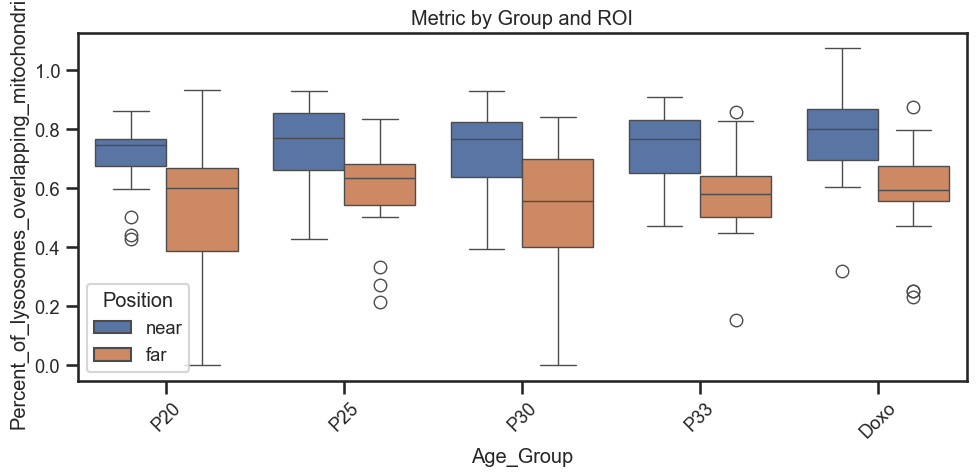

<Axes: xlabel='Age_Group', ylabel='Percent_of_lysosomes_overlapping_mitochondria'>

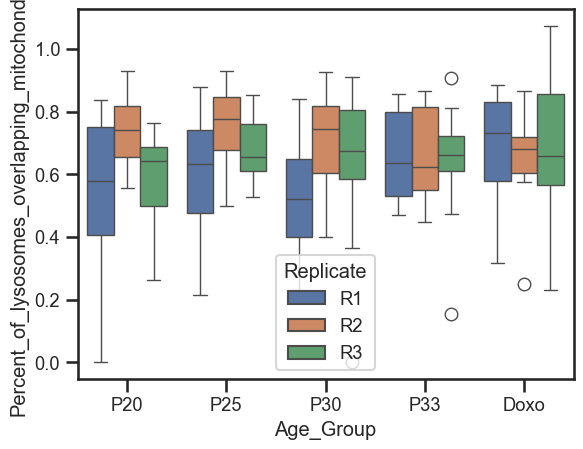

In [60]:

def plot_boxplots(df, group_col, roi_col, value_col, roi_values=None, title=None):
    plot_data = prepare_boxplot_data(df, group_col, roi_col, value_col, roi_values=roi_values)

    plt.figure(figsize=(10, 5))
    sns.boxplot(data=plot_data, x=group_col, y=value_col, hue=roi_col)
    plt.xticks(rotation=45)
    plt.title(title or f"Boxplot of {value_col} by {group_col} and {roi_col}")
    plt.tight_layout()
    #return plt.gcf()

# ------------------------------------------------------------
# Example usage
# ------------------------------------------------------------
# Uncomment the line below to generate a boxplot
plot_boxplots(combined_df, GROUP_COL, ROI_COL, VALUE_COL, roi_values=ROI_VALUES, title="Metric by Group and ROI")
plt.show()
sns.boxplot(data=combined_df, x=GROUP_COL, y=VALUE_COL, hue="Replicate")
# Preview outputs


[('P20', 'P25'), ('P20', 'P30'), ('P20', 'P33'), ('P20', 'Doxo'), ('P25', 'P30'), ('P25', 'P33'), ('P25', 'Doxo'), ('P30', 'P33'), ('P30', 'Doxo'), ('P33', 'Doxo')]


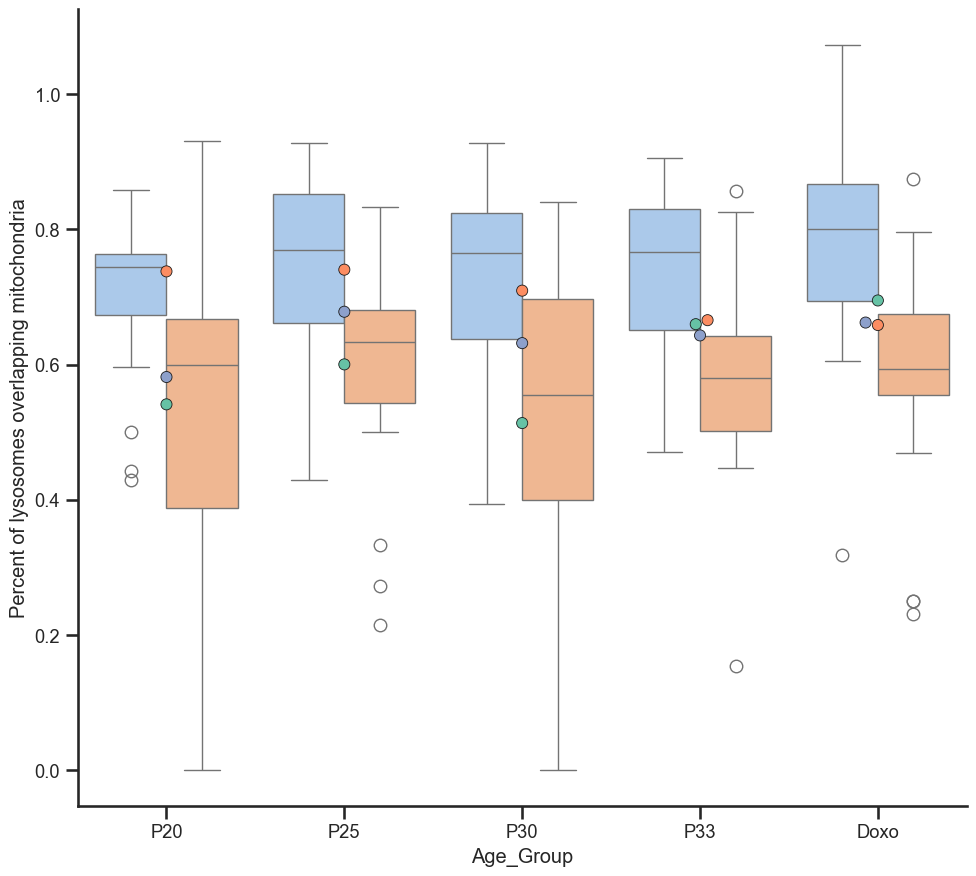

In [69]:
def simple_paired_superboxplot(
    data_df,
    x_value,
    y_value,
    hue_value,
    plate_col_name="Replicate",
    pairs=None,
    order=None,
    ytitle=None,
    xtitle=None,
    ylim=None,
    pallete="Set2",
    figsize=(10, 9),
    context="talk",
    dpi=300,
    legend=False,
):
    # Set values to defaults if a parameter is not loaded for order or y axis parameters
    if ytitle is None:
        ytitle = y_value.replace("_", " ")
    if order is None:
        order = data_df[x_value].dropna().unique().tolist()
    if xtitle is None:
        xtitle = x_value

    pairs = getpairs(data_df, x_value, order)
    print(pairs)

    group_avg_df = (
        data_df.groupby([x_value, plate_col_name], dropna=False)[y_value]
        .agg("mean")
        .reset_index()
    )

    sns.set_theme(style="ticks")
    plt.figure(figsize=figsize)  # , dpi=dpi)
    sns.set_context(context, font_scale=0.8)

    sns.boxplot(
        data=data_df,
        x=x_value,
        y=y_value,
        hue=hue_value,
        order=order,
        palette="pastel",
        dodge=True,
    )
    ax = sns.swarmplot(
        data=group_avg_df,
        x=x_value,
        y=y_value,
        hue=plate_col_name,
        order=order,
        palette=pallete,
        dodge=False,
        size=8,
        edgecolor="k",
        linewidth=0.6,
        legend=False,
    )

    if legend:
        ax.legend(title=hue_value, bbox_to_anchor=(1.05, 1), loc="upper left")
    else:
        ax.legend_.remove()

    sns.despine()
    plt.tight_layout()
    plt.xlabel(xtitle)
    plt.ylabel(ytitle)
    plt.ylim(ylim)
    plt.savefig(xtitle + "_" + y_value + "_swarmplot.png", dpi=dpi)
    plt.show()

simple_paired_superboxplot(
    data_df=combined_df,
    x_value=GROUP_COL,
    y_value=VALUE_COL,
    hue_value=ROI_COL,
    plate_col_name="Replicate",
    order=None)

In [61]:
def get_multilevel_pairs(df, x_val, hue_val):
    pairs = []
    for x_level in sorted(df[x_val].dropna().unique()):
        levels = sorted(df.loc[df[x_val] == x_level, hue_val].astype(str).dropna().unique())
        for a, b in combinations(levels, 2):
            pairs.append((f"{x_level}_{a}", f"{x_level}_{b}"))
    return pairs

In [65]:
def simple_paired_superboxplot_with_annotation(
    data_df,
    x_value,
    y_value,
    hue_value,
    plate_col_name="Replicate",
    pairs=None,
    order=None,
    annotate=False,
    test="tukey",
    ytitle=None,
    xtitle=None,
    ylim=None,
    pallete="Set2",
    figsize=(10, 9),
    context="talk",
    dpi=300,
    legend=False,
):
    # Set values to defaults if a parameter is not loaded for order or y axis parameters
    if ytitle is None:
        ytitle = y_value.replace("_", " ")
    if xtitle is None:
        xtitle = x_value

    pairs = get_multilevel_pairs(data_df, x_value, hue_value)
    print(pairs)
    
    data_df["group_combo"] = data_df[x_value].astype(str) + "_" + data_df[hue_value].astype(str)
    if order is None:
        order = data_df["group_combo"].dropna().unique().tolist()
    
    group_avg_df = (
        data_df.groupby(["group_combo", plate_col_name], dropna=False)[y_value]
        .agg("mean")
        .reset_index()
    )
    display(group_avg_df)

    sns.set_theme(style="ticks")
    plt.figure(figsize=figsize)  # , dpi=dpi)
    sns.set_context(context, font_scale=0.8)

    sns.boxplot(
        data=data_df,
        x="group_combo",
        y=y_value,
       # hue=hue_value,
        order=order,
        palette="pastel",
        dodge=True,
    )
    ax = sns.swarmplot(
        data=group_avg_df,
        x="group_combo",
        y=y_value,
       hue=plate_col_name,
        order=order,
        palette=pallete,
        dodge=False,
        size=8,
        edgecolor="k",
        linewidth=0.6,
        legend=False,
    )

    if legend:
        ax.legend(title=hue_value, bbox_to_anchor=(1.05, 1), loc="upper left")
        # ax = annotate_legend_with_shapiro(ax, group_avg_df_shapiro, plate_col_name)
    else:
        ax.legend_.remove()
        # ax.legend_.remove()

    sns.despine()
    plt.tight_layout()
    plt.xlabel(xtitle)
    plt.ylabel(ytitle)
    plt.ylim(ylim)
    if annotate and test is not None:
        try:
            print(test)
            ax = annotate_pairs_with_calculated_pvalues_test(
                ax,
                group_avg_df,
                None,
                "group_combo",
                y_value,
                plate_col_name=plate_col_name,
                test_name=test,
                order=order,
                plot_type="boxplot",
            )
        except Exception as e:
            print(f"Error annotating with statistical test: {e}")

    plt.savefig(xtitle + "_" + y_value + "_swarmplot.png", dpi=dpi)
    plt.show()


In [68]:
def pvalues_tukey_pingouin(
    data_df,
    x_value,
    y_value,
    display=False,
):
    """Perform Tukey's post-hoc test on the data. Uses Tukey-Kramer method with sample size with the Pingouin package.
    See https://pingouin-stats.org/build/html/guidelines.html for a flowchart
    Args:
        data_df (pd.DataFrame): DataFrame table containing the data.
        pivot_df (pd.DataFrame): DataFrame pivot table containing the means.
        x_value (str): Column name for the independent variable.
        y_value (str): Column name for the dependent variable.
        grouping_variable (str): Column name for the plate number.
        order (list, optional): Order of groups for plotting. Defaults to None.

    Returns:
     (pairs,pvalues) (tuple): pairs and corresponding p values
    """
    import pingouin as pg

    df = data_df.copy()

    tukey_result = pg.pairwise_tukey(
        data=df, dv=y_value, between=x_value
    )  # .round(3)
    # this is a dataframe; get the pairs and the pvalue cols
    result_pairs = tukey_result[["A", "B"]].itertuples(index=False, name=None)
    pairs = list(result_pairs)

    p_value_col = None
    for candidate in ["p_tukey", "p-tukey"]:
        if candidate in tukey_result.columns:
            p_value_col = candidate
            break

    if p_value_col is None:
        raise KeyError(
            f"Unable to find a Tukey p-value column in Pingouin output. Available columns: {list(tukey_result.columns)}"
        )

    p_values = tukey_result[p_value_col].tolist()
    if display:
        pg.print_table(tukey_result)
        #display(tukey_result_df)
    return (pairs, p_values)

def annotate_pairs_with_calculated_pvalues_test(
    ax,
    data,
    pivot_data,
    x_value,
    y_value,
    plate_col_name="Plate_Name",
    test_name="tukey",
    pairs=None,
    order=None,
    plot_type="boxplot",
    show_test_name=False,
    p_correction="fdr_bh",
    annotation_location="inside",
):
    """Add statistical annotations to a plot using a multiple comparisons test in the statsmodels, scipy, or scikit-posthocs modules.
    see https://statannotations.readthedocs.io/en/latest/custom-test.html for more examples
    Also see https://www.graphpad.com/guides/prism/latest/statistics/stat_summary_of_multiple_comparison.htm for a list of posthoc tests and when to use them

    Args:
        ax (Matplotlib Axes Object): the axis of the graph to annoate
        data (DataFrame): dataframe from a grouped feature df containing the groups aggregated by plate to analyze in "tidy" format
        pivot_data (DataFrame): the grouped feature df in matrix format
        x_value (str): independent variable on x axis
        y_value (str): dependent variable on y axis
        plate_col_name (str, optional): the col containing the experimental plate. Defaults to "Plate_Name".
        test_name (str, optional): the statistical test to perform. Accepts values of "tukey", "anova", or "tukey_v2", for ANOVA with Tukey's HSD, "tukey_v3" for ANOVA with Tukey HSD with Tukey-Kramer correction, "games-howell" or "games" for ANOVA with Games-Howell posthoc, "rmanova" for repeated-measures ANOVA using Welch's ttest with the specified p-value correction, "kruskal" or "dunn" for classic nonparametric multiple comparisons with Dunn's postc, "conover" for kruskal with Conover's posthoc, "nemenyi" for kruskal (or friedman) with Nemenyi's posthoc for repeated measures, "pairwise_ttest" for corrected ttests, "pairwise_mwu" for nonparametic multiple comparisons. Defaults to "tukey".
        pairs (list of str, optional): The pairs of x_value for the comparisons. Defaults to None, is automatically calculated otherwise based on the getpairs() function.
        order (listlike, optional): _description_. Defaults to None.
        plot (str, optional): the type of plot to annotate. Defaults to "boxplot".
        p_correction (str, optional): the p-value correction to use if applicable. Deaults to Benjamini/Hochberg "fdr_bh" (non-negative) method ; graphpad reccomneds as its less hemmoraging to your power. Also accepts "holm", "sidak", "bonferroni", "holm-sidak" and Benjamini/Yekutieli "fdr-by" for negative values. See https://scikit-posthocs.readthedocs.io/en/latest/generated/scikit_posthocs.posthoc_mannwhitney.html for other options

    Returns:
        _type_: _description_
    """
    from statannotations.Annotator import Annotator

    if pairs is None:
        pairs = getpairs(data, x_value, order=order)

    if test_name in ["tukey", "tukey_pingouin"]:
        used_pairs, p_values = pvalues_tukey_pingouin(
            data,
            x_value=x_value,
            y_value=y_value,
            display=True,
        )
    elif test_name in ["tukey_anova", "tukey_anova_pingouin"]:
        used_pairs, p_values = pvalues_anova_with_tukey_pingouin(
            data,
            pivot_data,
            x_value=x_value,
            y_value=y_value,
            plate_number_col=plate_col_name,
            order=order,
            desired_pairs=pairs,
            display=True,
        )
    else:
        raise ValueError(
            f"Test name '{test_name}' is invalid. Use 'tukey', 'tukey_anova'"
        )
    if used_pairs is None or len(used_pairs) == 0:
        print(f"No significant pairs found for the {test_name} test.")
        return ax
    else:
        annotator = Annotator(
            ax=ax,
            pairs=list(used_pairs),
            data=data,
            plot=plot_type,
            x=x_value,
            y=y_value,
            order=order,
        )
        annotator.reset_configuration()
        # see https://raw.githubusercontent.com/trevismd/statannotations/3f020ae631ca88a091b6ee3e9a9fd32158920879/usage/example_tuning_y_offsets_w_arguments.png
        annotator.configure(
            text_format="full",
            test_short_name=test_name,
            pvalue_format_string="{:.4f}",
            fontsize="small",
            # pvalue_format = [[1e-5, "1e-5"], [1e-4, "1e-4"], [1e-3, "0.001"], [1e-2, "0.01"], [5e-2, "0.05"]],
            loc=annotation_location,
            hide_non_significant=True,
            color="black",
            verbose=2,
            line_height=0.01,
            text_offset=0.8,
            # line_offset_to_group=0.01,
            # line_offset=0.01,
            show_test_name=show_test_name,
        )
        annotator.set_pvalues_and_annotate(p_values)
        return ax

[('Doxo_far', 'Doxo_near'), ('P20_far', 'P20_near'), ('P25_far', 'P25_near'), ('P30_far', 'P30_near'), ('P33_far', 'P33_near')]


,group_combo,Replicate,Percent_of_lysosomes_overlapping_mitochondria
0,Doxo_far,R1,0.646522
1,Doxo_far,R2,0.576258
2,Doxo_far,R3,0.513637
3,Doxo_near,R1,0.743062
4,Doxo_near,R2,0.740606
5,Doxo_near,R3,0.810544
6,P20_far,R1,0.412033
7,P20_far,R2,0.695873
8,P20_far,R3,0.515006
9,P20_near,R1,0.670003


tukey


/var/folders/yd/1fhlg3pn6d74xlj_wkkzgcrc0000gn/T/ipykernel_75148/1372001201.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/yd/1fhlg3pn6d74xlj_wkkzgcrc0000gn/T/ipykernel_75148/1372001201.py:68: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title=hue_value, bbox_to_anchor=(1.05, 1), loc="upper left")



POST HOC TESTS

A          B            mean_A    mean_B    diff     se       T    p_tukey    hedges
---------  ---------  --------  --------  ------  -----  ------  ---------  --------
Doxo_far   Doxo_near     0.579     0.765  -0.186  0.070  -2.647      0.259    -2.717
Doxo_far   P20_far       0.579     0.541   0.038  0.070   0.539      1.000     0.270
Doxo_far   P20_near      0.579     0.702  -0.124  0.070  -1.760      0.751    -1.478
Doxo_far   P25_far       0.579     0.597  -0.018  0.070  -0.258      1.000    -0.178
Doxo_far   P25_near      0.579     0.744  -0.165  0.070  -2.355      0.399    -1.729
Doxo_far   P30_far       0.579     0.524   0.055  0.070   0.785      0.998     0.678
Doxo_far   P30_near      0.579     0.714  -0.135  0.070  -1.927      0.653    -0.954
Doxo_far   P33_far       0.579     0.578   0.001  0.070   0.008      1.000     0.009
Doxo_far   P33_near      0.579     0.731  -0.153  0.070  -2.173      0.503    -2.397
Doxo_near  P20_far       0.765     0.541   0.224

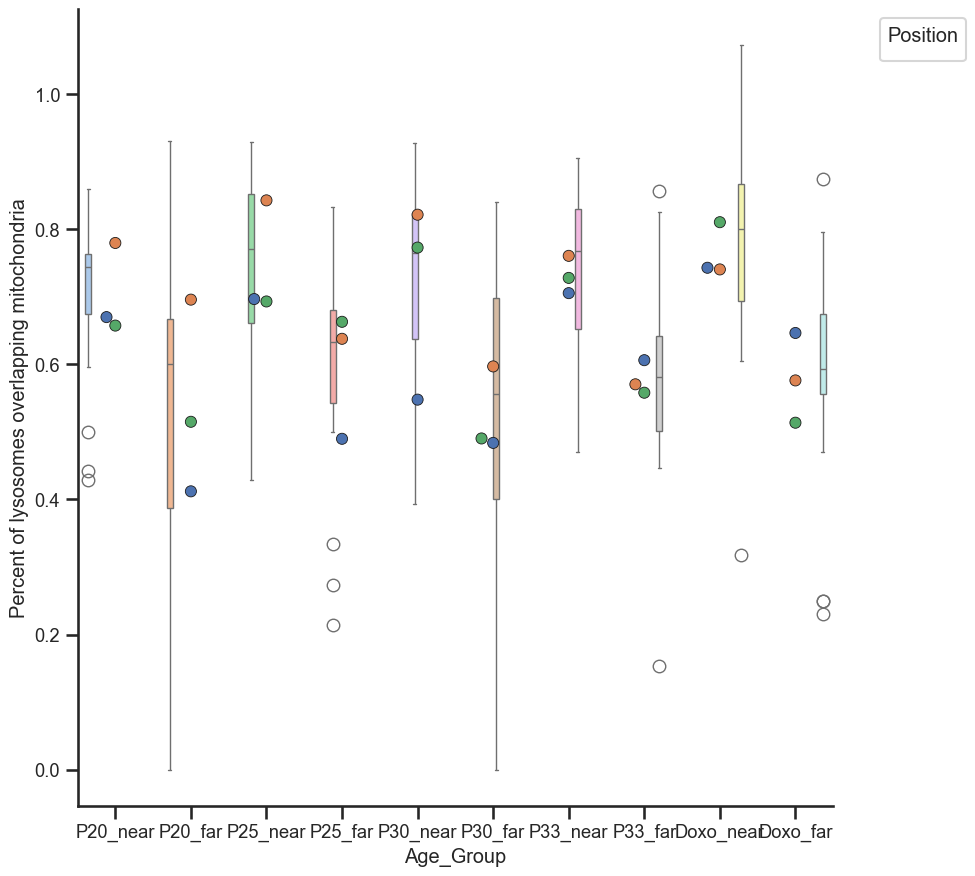

In [67]:
simple_superswarmplot = simple_paired_superboxplot_with_annotation(
    data_df=combined_df,
    x_value=GROUP_COL,
    y_value=VALUE_COL,
    hue_value=ROI_COL,
    plate_col_name="Replicate",
    pairs=None,
    order=None,
    annotate=True,
    test="tukey",
    ytitle=None,
    xtitle=None,
    ylim=None,
    pallete=None,
    figsize=(10, 9),
    context="talk",
    dpi=300,
    legend=True,
)